In [6]:
import osmnx as ox
import matplotlib.pyplot as plt
import networkx as nx
import random
from shapely.geometry import LineString, Point
import numpy as np

In [7]:
def extract_taxiway_graph(place_name):
    tags = {"aeroway": ["taxiway", "runway"]}
    gdf = ox.features_from_place(place_name, tags)
    
    # Create a NetworkX graph
    G = nx.Graph()
    
    for idx, row in gdf.iterrows():
        geom = row.geometry
        if isinstance(geom, LineString):
            coords = list(geom.coords)
            # Add nodes and edges
            for i in range(len(coords) - 1):
                start = coords[i]
                end = coords[i + 1]
                G.add_edge(start, end, 
                          geometry=LineString([start, end]),
                          aeroway=row.get('aeroway', 'taxiway'),
                          name=row.get('name', ''))
    
    return G

def get_gates_and_runways(place_name):
    # Get gates
    try:
        gate_tags = {"aeroway": "gate"}
        gates_gdf = ox.features_from_place(place_name, gate_tags)
        gates = []
        for idx, row in gates_gdf.iterrows():
            if hasattr(row.geometry, 'x'):  # Point geometry
                gates.append({
                    'id': row.get('ref', f'G{idx}'),
                    'position': (row.geometry.x, row.geometry.y),
                    'terminal': row.get('terminal', 'Unknown')
                })
    except:
        # creates some mock gates near the airport
        print("No gates found in OSM data, creating mock gates...")
        gates = [
            {'id': 'A12', 'position': (-87.9048, 41.9786), 'terminal': 'Terminal 1'},
            {'id': 'B15', 'position': (-87.9058, 41.9796), 'terminal': 'Terminal 2'},
            {'id': 'C22', 'position': (-87.9068, 41.9806), 'terminal': 'Terminal 3'},
            {'id': 'K10', 'position': (-87.9078, 41.9816), 'terminal': 'Terminal 5'},
        ]
    
    # Get runways
    tags = {"aeroway": "runway"}
    runway_gdf = ox.features_from_place(place_name, tags)
    runways = []
    
    for idx, row in runway_gdf.iterrows():
        runway_name = row.get('name', row.get('ref', f'RWY{idx}'))
        if isinstance(row.geometry, LineString):
            coords = list(row.geometry.coords)
            runways.append({
                'name': runway_name,
                'start': coords[0],
                'end': coords[-1],
                'geometry': row.geometry
            })
    
    return gates, runways

In [8]:
class Aircraft:
    def __init__(self, callsign, aircraft_type="B738"):
        self.callsign = callsign
        self.aircraft_type = aircraft_type
        self.current_position = None
        self.gate = None
        self.destination_runway = None
        self.path = []
        self.path_index = 0
        self.status = "AT_GATE"
        
    def assign_gate(self, gate):
        self.gate = gate
        self.current_position = gate['position']
        print(f"{self.callsign} assigned to gate {gate['id']} at {gate['terminal']}")

class ATCController:
    # simple ATC controller
    def __init__(self, graph, gates, runways):
        self.graph = graph
        self.gates = gates
        self.runways = runways
        
    def find_nearest_taxiway_node(self, position):
        min_dist = float('inf')
        nearest_node = None
        
        for node in self.graph.nodes():
            dist = ((position[0] - node[0])**2 + (position[1] - node[1])**2)**0.5
            if dist < min_dist:
                min_dist = dist
                nearest_node = node
                
        return nearest_node
    
    def plan_taxi_route(self, aircraft, runway_name):
        if not aircraft.current_position:
            return []
            
        # Find nearest taxiway node to gate
        start_node = self.find_nearest_taxiway_node(aircraft.current_position)
        
        # Find runway nodes
        runway = None
        for r in self.runways:
            if runway_name.lower() in r['name'].lower():
                runway = r
                break
        
        if not runway:
            runway = self.runways[0] if self.runways else None
            
        if not runway:
            return []
            
        # Find nearest taxiway node to runway
        end_node = self.find_nearest_taxiway_node(runway['start'])
        
        try:
            # Calculate shortest path
            path = nx.shortest_path(self.graph, start_node, end_node)
            return path
        except nx.NetworkXNoPath:
            print(f"No path found from gate to runway {runway_name}")
            return []
    
    def get_actual_taxiway_names(self, path):
    
        taxiway_names = []

        for i in range(len(path) - 1):
            start_node = path[i]
            end_node = path[i + 1]

            # Find the edge between these nodes
            if self.graph.has_edge(start_node, end_node):
                edge_data = self.graph[start_node][end_node]
                # Get the name from edge data
                name = edge_data.get('name', '')

                # Convert to string and strip if it's not already a string
                if name is not None and str(name).lower() not in ['nan', 'none', '']:
                    name = str(name).strip()
                else:
                    name = ''

                # Only add non-empty, unique taxiway names
                if name and name not in taxiway_names:
                    # Convert to phonetic if it's a single letter
                    if len(name) == 1 and name.isalpha():
                        phonetic_map = {'A': 'Alpha', 'B': 'Bravo', 'C': 'Charlie', 
                                      'D': 'Delta', 'E': 'Echo', 'F': 'Foxtrot',
                                      'G': 'Golf', 'H': 'Hotel', 'K': 'Kilo',
                                      'L': 'Lima', 'M': 'Mike', 'N': 'November'}
                        name = phonetic_map.get(name.upper(), name)
                    taxiway_names.append(name)

            return taxiway_names[:4]
    
    def issue_clearance(self, aircraft):
        # Assign runway
        runway = random.choice(self.runways) if self.runways else {'name': '28L'}
        aircraft.destination_runway = runway['name']

        # Plan route
        path = self.plan_taxi_route(aircraft, runway['name'])
        aircraft.path = path

        if path:
            # Get actual taxiway names from the route
            taxiway_names = self.get_actual_taxiway_names(path)

            # Generate realistic ATC instruction with actual taxiway names
            if taxiway_names:
                via_taxiways = ", ".join(taxiway_names)
                instruction = f"{aircraft.callsign}, taxi to runway {runway['name']} via {via_taxiways}, hold short of runway"
            else:
                instruction = f"{aircraft.callsign}, taxi to runway {runway['name']}, hold short of runway"

            print(f"ATC: {instruction}")
            print(f"Route uses taxiways: {taxiway_names if taxiway_names else ['Unnamed taxiways']}")
            aircraft.status = "TAXIING"
            return instruction
        else:
            instruction = f"{aircraft.callsign}, unable to route to runway {runway['name']}"
            print(f"ATC: {instruction}")
            return instruction

In [9]:
def visualize_taxi_navigation(place_name="O'Hare International Airport, Chicago, Illinois, USA"):
    print(f"Setting up navigation for {place_name}")
    
    # Get airport data
    print("Downloading airport data...")
    G = extract_taxiway_graph(place_name)
    gates, runways = get_gates_and_runways(place_name)
    
    print(f"Found {len(G.nodes)} taxiway nodes")
    print(f"Found {len(gates)} gates")
    print(f"Found {len(runways)} runways")
    
    # Create ATC and aircraft
    atc = ATCController(G, gates, runways)
    aircraft = Aircraft("UAL456", "A320")
    
    # Assign gate
    if gates:
        gate = random.choice(gates)
        aircraft.assign_gate(gate)
    else:
        print("No gates available")
        return
    
    # Get ATC clearance
    pushback_msg = f"{aircraft.callsign}, pushback approved, contact ground when ready"
    print(f"ATC: {pushback_msg}")
    
    clearance = atc.issue_clearance(aircraft)
    
    # Visualize
    fig, ax = plt.subplots(figsize=(15, 10))
    
    # Draw taxiway network
    print("Drawing airport map...")
    for u, v, data in G.edges(data=True):
        geom = data.get('geometry')
        if geom and isinstance(geom, LineString):
            x, y = geom.xy
            color = 'white' if data.get('aeroway') == 'runway' else 'lightgray'
            width = 4 if data.get('aeroway') == 'runway' else 1
            ax.plot(x, y, color=color, linewidth=width, alpha=0.7)
    
    # Draw gates
    for gate in gates:
        pos = gate['position']
        ax.plot(pos[0], pos[1], 'bo', markersize=8, label='Gates' if gate == gates[0] else "")
        ax.text(pos[0], pos[1]+0.001, gate['id'], fontsize=8, ha='center', color='blue')
    
    # Draw runways endpoints
    for runway in runways:
        start, end = runway['start'], runway['end']
        ax.plot([start[0], end[0]], [start[1], end[1]], 'yellow', linewidth=6, alpha=0.8)
        mid_x, mid_y = (start[0] + end[0])/2, (start[1] + end[1])/2
        ax.text(mid_x, mid_y, runway['name'], fontsize=10, ha='center', 
               bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))
    
    # Draw aircraft and path
    if aircraft.path:
        # Draw planned path
        path_x = [pos[0] for pos in aircraft.path]
        path_y = [pos[1] for pos in aircraft.path]
        ax.plot(path_x, path_y, 'r--', linewidth=3, alpha=0.8, label='Taxi Route')
        
        # Mark waypoints
        ax.scatter(path_x, path_y, c='red', s=30, alpha=0.8, zorder=10)
        
        print(f"Planned taxi route: {len(aircraft.path)} waypoints")
        print(f"Distance: {nx.shortest_path_length(G, aircraft.path[0], aircraft.path[-1]):.0f} units")
    
    # Draw aircraft at gate
    gate_pos = aircraft.current_position
    ax.plot(gate_pos[0], gate_pos[1], 's', color='red', markersize=15, 
           markeredgecolor='white', markeredgewidth=2, label=aircraft.callsign)
    ax.text(gate_pos[0], gate_pos[1]+0.002, aircraft.callsign, 
           fontsize=12, ha='center', color='red', fontweight='bold')
    
    # Styling
    ax.set_aspect('equal')
    ax.set_title(f'{place_name}\n{aircraft.callsign} - Gate {aircraft.gate["id"]} to Runway {aircraft.destination_runway}', 
                fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add ATC message box
    textstr = f'Latest ATC: {clearance}'
    props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
           verticalalignment='top', bbox=props, wrap=True)
    
    plt.tight_layout()
    plt.show()
    
    # Return objects for further interaction
    return aircraft, atc, G

def animate_taxi_movement(aircraft, atc, G, step_delay=1.0):
    if not aircraft.path:
        print("No taxi route planned!")
        return
    
    print(f"Starting taxi animation for {aircraft.callsign}")
    print(f"Route: {len(aircraft.path)} waypoints")
    
    # Create animated plot
    fig, ax = plt.subplots(figsize=(15, 10))
    
    for step, position in enumerate(aircraft.path):
        ax.clear()
        
        # Draw taxiway network
        for u, v, data in G.edges(data=True):
            geom = data.get('geometry')
            if geom and isinstance(geom, LineString):
                x, y = geom.xy
                color = 'white' if data.get('aeroway') == 'runway' else 'lightgray'
                width = 4 if data.get('aeroway') == 'runway' else 1
                ax.plot(x, y, color=color, linewidth=width, alpha=0.7)
        
        # Draw full planned path
        path_x = [pos[0] for pos in aircraft.path]
        path_y = [pos[1] for pos in aircraft.path]
        ax.plot(path_x, path_y, 'orange', linewidth=2, alpha=0.5, linestyle='--')
        
        # Draw completed path
        if step > 0:
            completed_x = [pos[0] for pos in aircraft.path[:step+1]]
            completed_y = [pos[1] for pos in aircraft.path[:step+1]]
            ax.plot(completed_x, completed_y, 'green', linewidth=3, alpha=0.8)
        
        # Draw current aircraft position
        ax.plot(position[0], position[1], 's', color='red', markersize=15, 
               markeredgecolor='white', markeredgewidth=2)
        ax.text(position[0], position[1]+0.002, aircraft.callsign, 
               fontsize=12, ha='center', color='red', fontweight='bold')
        
        # Update title with progress
        progress = f"Step {step + 1}/{len(aircraft.path)}"
        ax.set_title(f'{aircraft.callsign} Taxi Progress - {progress}', 
                    fontsize=14, fontweight='bold')
        
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        
        plt.draw()
        plt.pause(step_delay)
        
        print(f"  Step {step + 1}: Position {position}")
    
    print(f"{aircraft.callsign} has reached runway {aircraft.destination_runway}!")
    
    # Final message
    final_clearance = f"{aircraft.callsign}, contact tower 120.15, good day"
    print(f"ATC: {final_clearance}")
    
    plt.show()

Setting up navigation for O'Hare International Airport, Chicago, Illinois, USA
Found 6244 taxiway nodes
Found 225 gates
Found 8 runways
UAL456 assigned to gate H3A/H3B at Unknown
ATC: UAL456, pushback approved, contact ground when ready
ATC: UAL456, taxi to runway 4L/22R, hold short of runway
Route uses taxiways: ['Unnamed taxiways']
Drawing airport map...
Planned taxi route: 71 waypoints
Distance: 70 units


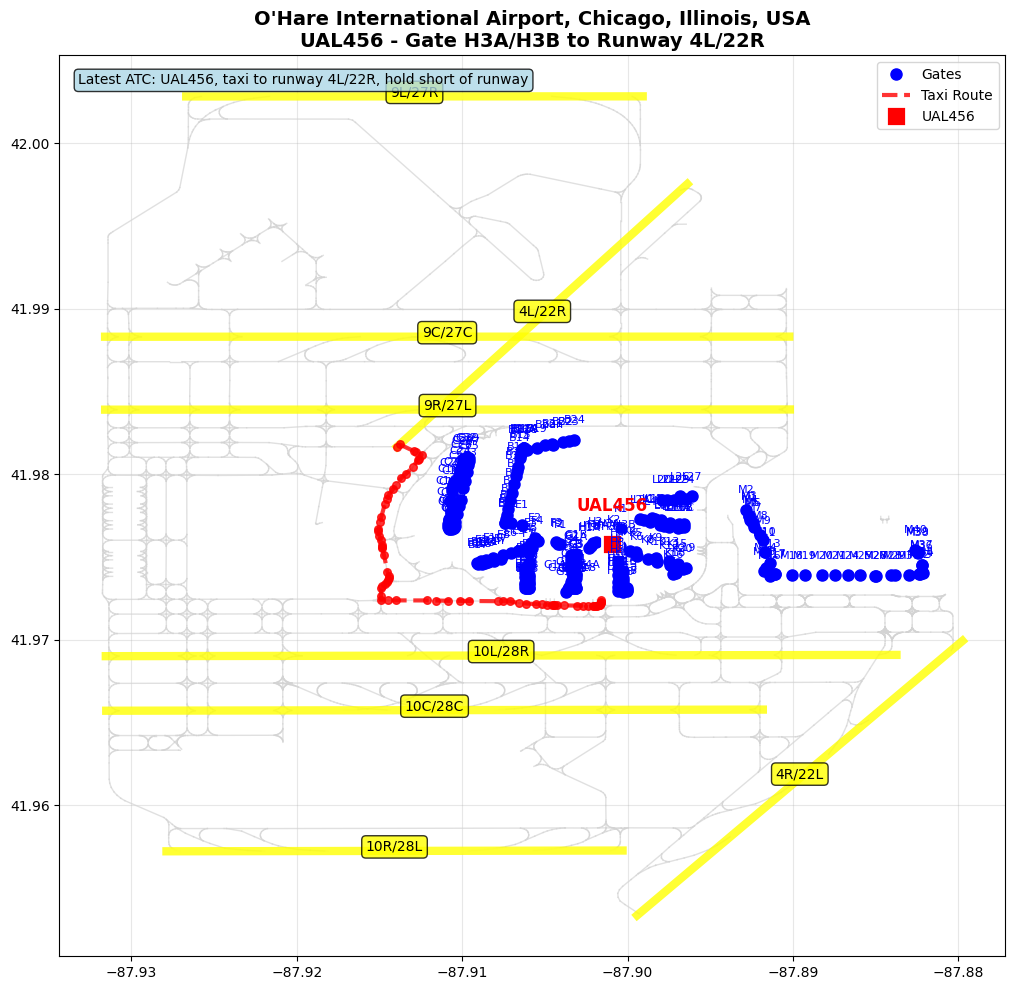

In [10]:
aircraft, atc, G = visualize_taxi_navigation()